# **Baseline Regression Evaluation**
### **Objective:** Establish a performance floor for `delivery_time_hours` prediction using Linear and Ridge regression with a time-aware validation strategy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Load Data
df = pd.read_csv('Dataset/final_dataset.csv')
target = 'delivery_time_hours'

print(f"✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")

✅ Dataset loaded: 69926 rows, 29 columns.


## **STEP 1: Time-Aware Data Partitioning**
Sorting by `order_date` and performing an 80/20 split to simulate real-world production deployment.

In [2]:
df['order_date'] = pd.to_datetime(df['order_date'])
df = df.sort_values('order_date').reset_index(drop=True)

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df.drop(columns=[target, 'order_date'])
y_train = train_df[target]
X_test = test_df.drop(columns=[target, 'order_date'])
y_test = test_df[target]

cat_features = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 55940 | Test size: 13986


## **STEP 2: Preprocessing and Modeling Pipeline**
Constructing a robust pipeline for scaling numeric data and encoding categorical variables.

In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    metrics = {
        'Model': name,
        'Train R2': r2_score(y_train, train_preds),
        'Test R2': r2_score(y_test, test_preds),
        'Train MAE': mean_absolute_error(y_train, train_preds),
        'Test MAE': mean_absolute_error(y_test, test_preds),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, train_preds)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_preds))
    }
    return metrics, test_preds

## **STEP 3: Model Training (Linear vs. Ridge)**
Using `TimeSeriesSplit` for hyperparameter tuning of the Ridge regularizer.

In [4]:
# Linear Regression
lr_pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', LinearRegression())])
lr_pipeline.fit(X_train, y_train)
lr_metrics, lr_preds = evaluate_model(lr_pipeline, X_train, y_train, X_test, y_test, 'Linear Regression')

# Ridge Regression with CV
ridge_pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', Ridge())])
param_grid = {'regressor__alpha': [0.1, 1.0, 10.0, 100.0]}
tscv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(ridge_pipeline, param_grid, cv=tscv, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

ridge_best = grid_search.best_estimator_
ridge_metrics, ridge_preds = evaluate_model(ridge_best, X_train, y_train, X_test, y_test, f"Ridge (α={grid_search.best_params_['regressor__alpha']})")

## **STEP 4: Results and Residual Analysis**

,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Linear Regression,0.978949,0.979279,0.627259,0.629221,0.876185,0.866885
1,Ridge (α=1.0),0.978949,0.979279,0.627233,0.629191,0.876185,0.866880


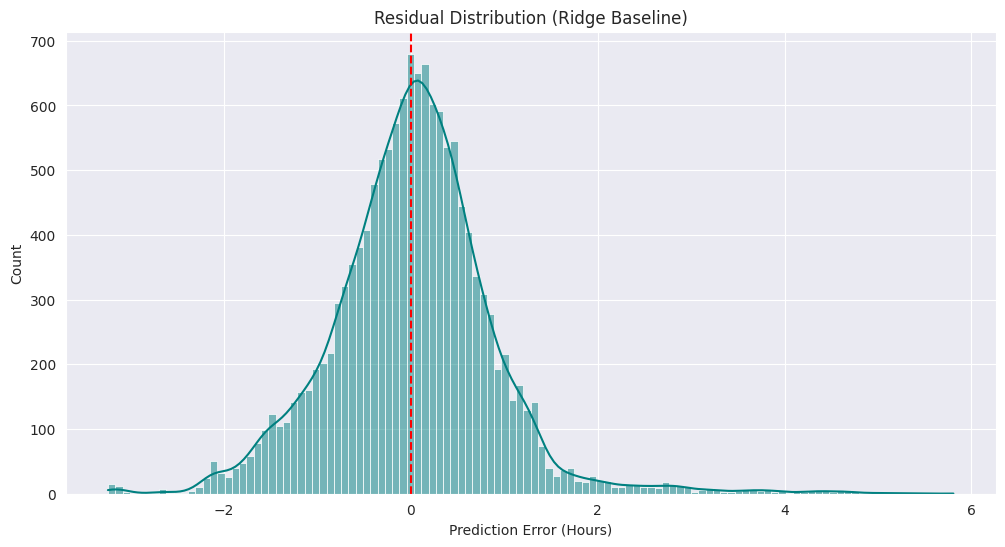

In [6]:
results_df = pd.DataFrame([lr_metrics, ridge_metrics])
display(results_df)

plt.figure(figsize=(12, 6))
residuals = y_test - ridge_preds
sns.histplot(residuals, kde=True, color='teal')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residual Distribution (Ridge Baseline)')
plt.xlabel('Prediction Error (Hours)')
plt.show()